In [ ]:
import pandas as pd
from pathlib import Path

# Define output directory for all results
output_base_dir = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\woGeo')
output_base_dir.mkdir(parents=True, exist_ok=True)

# Load tallo.csv
data_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv')
df_tallo = pd.read_csv(data_path)

print(f'✓ Loaded: {data_path}')
print(f'✓ Output directory: {output_base_dir}')
print(f'\nShape: {df_tallo.shape}')
print(f'\nColumns: {list(df_tallo.columns)}')
print(f'\nFirst 5 rows:')
print(df_tallo.head())
print(f'\nData types:')
print(df_tallo.dtypes)
print(f'\nBasic statistics:')
print(df_tallo.describe())

✓ Loaded: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv
✓ Output directory: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus

Shape: (498838, 13)

Columns: ['tree_id', 'division', 'family', 'genus', 'species', 'latitude', 'longitude', 'stem_diameter_cm', 'height_m', 'crown_radius_m', 'height_outlier', 'crown_radius_outlier', 'reference_id']

First 5 rows:
  tree_id    division      family   genus           species  latitude  \
0     T_1  Angiosperm  Betulaceae  Betula  Betula pubescens    67.395   
1     T_2  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
2     T_3  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
3     T_4  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
4     T_5  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   

   longitude  stem_diameter_cm  height_m  crown_radius_m height_outlier  \
0     28.723              1

In [2]:
# Extract genus from species name and filter by genus
# First, extract genus (first word of species name)
df_tallo['genus'] = df_tallo['species'].str.split().str[0]

genus_to_keep = [
    'Fagus',
    'Alnus',
    'Fraxinus',
    'Populus',
    'Pinus',
    'Larix',
    'Abies',
    'Picea'
]

print(f'Original shape: {df_tallo.shape}')
print(f'\nGenus in dataset:')
print(df_tallo['genus'].value_counts())

# Filter to keep only the specified genera
df_tallo = df_tallo[df_tallo['genus'].isin(genus_to_keep)]

# Remove samples with diameter < 10 cm
df_tallo = df_tallo[df_tallo['stem_diameter_cm'] >= 10]

print(f'\n✓ Filtered to keep only specified genera and D >= 10 cm')
print(f'New shape: {df_tallo.shape}')
print(f'\nRemaining genera:')
print(df_tallo['genus'].value_counts())
print(f'\nSpecies per genus:')
for genus in sorted(df_tallo['genus'].unique()):
    species_list = df_tallo[df_tallo['genus'] == genus]['species'].unique()
    print(f'  {genus}: {", ".join(species_list)}')
print(f'\nFirst 5 rows:')
print(df_tallo.head())

Original shape: (498838, 13)

Genus in dataset:
genus
Quercus          69107
Pinus            66706
Eucalyptus       22989
Picea            13837
Fagus            13009
                 ...  
Tetraberlinia        1
Oxystigma            1
Detarium             1
Bikinia              1
Cocculus             1
Name: count, Length: 1452, dtype: int64

✓ Filtered to keep only specified genera and D >= 10 cm
New shape: (93376, 13)

Remaining genera:
genus
Pinus       60271
Picea       11365
Fagus       10349
Abies        5278
Fraxinus     2541
Populus      2215
Larix        1159
Alnus         198
Name: count, dtype: int64

Species per genus:
  Abies: Abies balsamea, Abies alba, Abies veitchii, Abies lasiocarpa, Abies firma, Abies sachalinensis, Abies grandis, Abies pindrow, Abies pinsapo, Abies sibirica, Abies nephrolepis, Abies holophylla, Abies concolor, Abies amabilis, Abies procera, Abies magnifica
  Alnus: Alnus incana, Alnus glutinosa, Alnus alnobetula, Alnus hirsuta, Alnus subcordata, A

In [3]:
# Export filtered dataset
output_path = output_base_dir / 'tallofiltered_genus.csv'
df_tallo.to_csv(output_path, index=False)

print(f'✓ Exported to: {output_path}')
print(f'\nFile details:')
print(f'  - Rows: {len(df_tallo):,}')
print(f'  - Columns: {len(df_tallo.columns)}')
print(f'  - Species: {df_tallo["species"].nunique()}')
print(f'\nFile size: {output_path.stat().st_size / 1024 / 1024:.2f} MB')

✓ Exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\tallofiltered_genus.csv

File details:
  - Rows: 93,376
  - Columns: 13
  - Species: 114

File size: 7.59 MB


In [4]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Define allometric model: D = a * H^b
def allometric_model(H, a, b):
    return a * H**b

# Dictionary to store results
allometry_results = {}

print('='*80)
print('D-H ALLOMETRIC RELATIONSHIPS BY GENUS')
print('='*80)

genus_list = sorted(df_tallo['genus'].unique())

for genus in genus_list:
    genus_data = df_tallo[df_tallo['genus'] == genus].copy()
    
    # Remove NaN values
    genus_data = genus_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    if len(genus_data) < 10:  # Skip if not enough data
        continue
    
    H = genus_data['height_m'].values
    D = genus_data['stem_diameter_cm'].values
    
    # Fit model using curve_fit
    try:
        popt, pcov = curve_fit(allometric_model, H, D, p0=[1, 0.5], maxfev=5000)
        a, b = popt
        
        # Calculate R-squared using log-linear regression
        H_log = np.log(H)
        D_log = np.log(D)
        slope, intercept, r_value, p_value, std_err = linregress(H_log, D_log)
        r_squared = r_value**2
        
        # Store results
        allometry_results[genus] = {
            'a': a,
            'b': b,
            'r_squared': r_squared,
            'n_samples': len(genus_data),
            'H_min': H.min(),
            'H_max': H.max(),
            'D_min': D.min(),
            'D_max': D.max()
        }
        
        print(f'\n{genus}')
        print(f'  Model: D = {a:.4f} × H^{b:.4f}')
        print(f'  R² = {r_squared:.4f}')
        print(f'  N = {len(genus_data):,}')
        print(f'  H range: {H.min():.2f} - {H.max():.2f} m')
        print(f'  D range: {D.min():.2f} - {D.max():.2f} cm')
    
    except Exception as e:
        print(f'\n{genus}: Error in fitting - {str(e)}')

print('\n' + '='*80)

D-H ALLOMETRIC RELATIONSHIPS BY GENUS

Abies
  Model: D = 1.4200 × H^1.0212
  R² = 0.6340
  N = 5,272
  H range: 1.40 - 53.90 m
  D range: 10.00 - 118.00 cm

Alnus
  Model: D = 1.6345 × H^0.9509
  R² = 0.5031
  N = 197
  H range: 3.50 - 40.00 m
  D range: 10.00 - 81.00 cm

Fagus
  Model: D = 1.5779 × H^0.9864
  R² = 0.3434
  N = 10,018
  H range: 1.50 - 55.30 m
  D range: 10.00 - 162.00 cm

Fraxinus
  Model: D = 4.8060 × H^0.5687
  R² = 0.3047
  N = 2,536
  H range: 1.50 - 47.80 m
  D range: 10.00 - 112.40 cm

Larix
  Model: D = 0.6493 × H^1.2501
  R² = 0.6694
  N = 1,155
  H range: 3.90 - 44.00 m
  D range: 10.00 - 82.00 cm

Picea
  Model: D = 1.2346 × H^1.0411
  R² = 0.6904
  N = 11,349
  H range: 1.70 - 96.00 m
  D range: 10.00 - 305.00 cm

Pinus
  Model: D = 7.0973 × H^0.5325
  R² = 0.3527
  N = 60,029
  H range: 1.50 - 61.20 m
  D range: 10.00 - 132.00 cm

Populus
  Model: D = 2.0986 × H^0.8493
  R² = 0.3746
  N = 2,212
  H range: 2.30 - 39.60 m
  D range: 10.00 - 103.50 cm



✓ Figure saved: DH_Curves_by_Genus.png


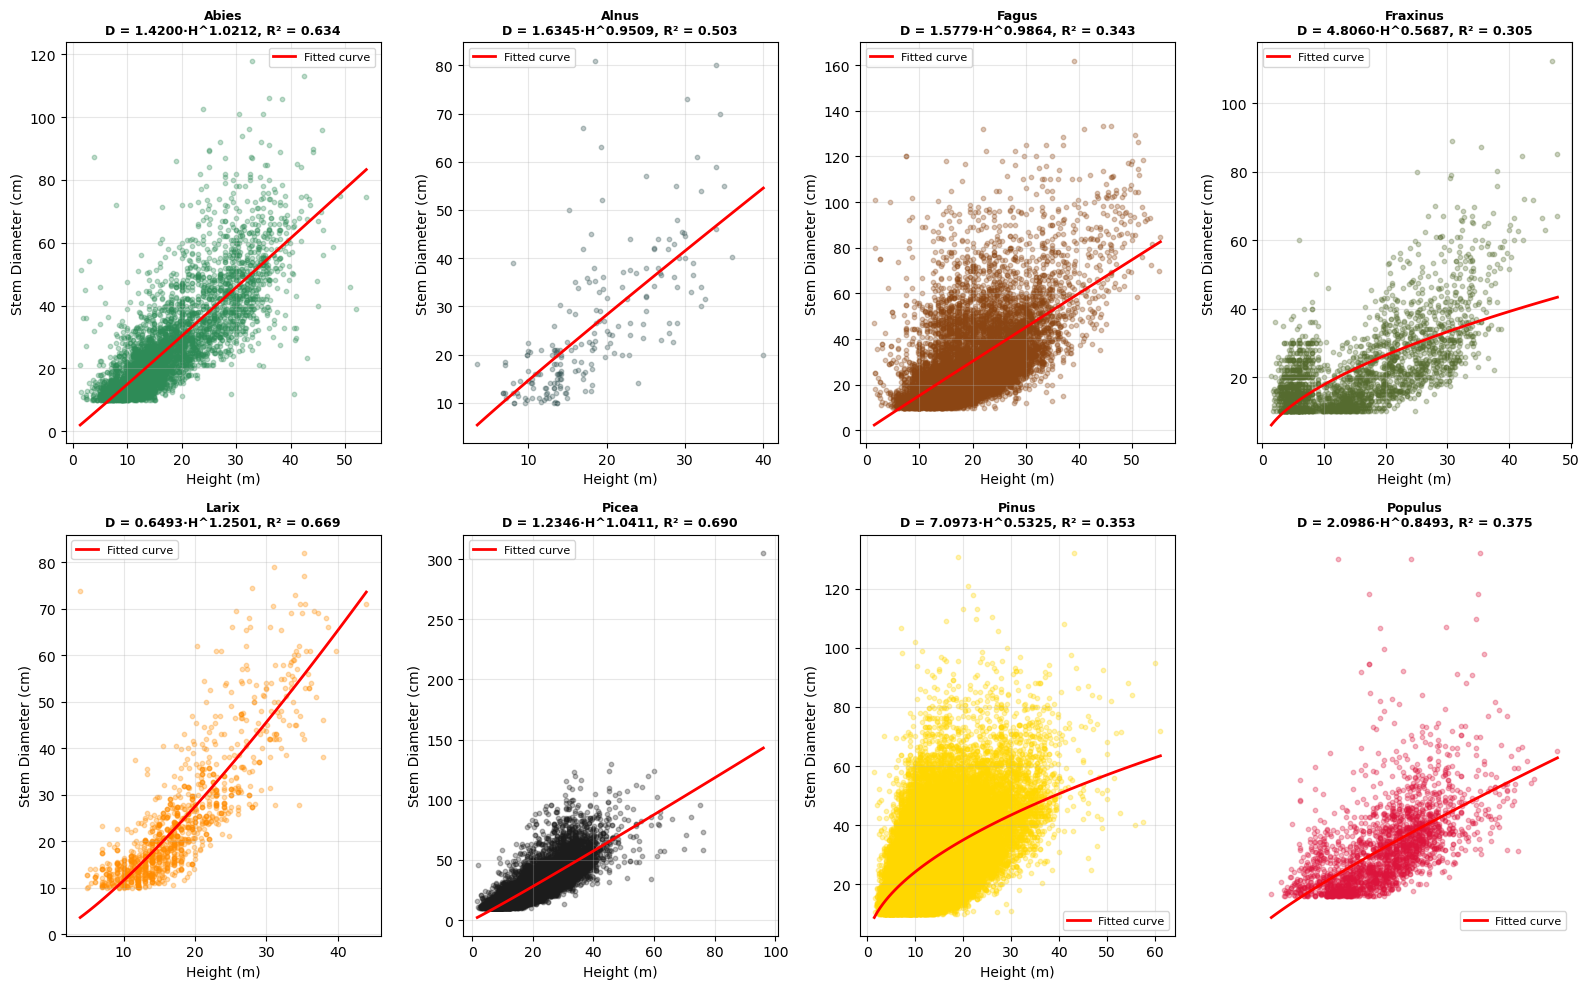

In [5]:
# Create visualization of D-H curves
colors = {
    'Fagus': '#8B4513',        # Brown
    'Alnus': '#2F4F4F',        # Dark slate gray
    'Fraxinus': '#556B2F',     # Dark olive green
    'Populus': '#DC143C',      # Crimson
    'Pinus': '#FFD700',        # Gold
    'Larix': '#FF8C00',        # Dark orange
    'Abies': '#2E8B57',        # Forest green
    'Picea': '#1C1C1C'         # Dark charcoal
}

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, genus in enumerate(sorted(allometry_results.keys())):
    ax = axes[idx]
    
    genus_data = df_tallo[df_tallo['genus'] == genus].dropna(subset=['stem_diameter_cm', 'height_m'])
    H = genus_data['height_m'].values
    D = genus_data['stem_diameter_cm'].values
    
    result = allometry_results[genus]
    a, b = result['a'], result['b']
    r_sq = result['r_squared']
    
    # Plot raw data
    ax.scatter(H, D, alpha=0.3, s=10, color=colors.get(genus, 'gray'))
    
    # Plot fitted curve
    H_range = np.linspace(H.min(), H.max(), 100)
    D_fitted = allometric_model(H_range, a, b)
    ax.plot(H_range, D_fitted, 'r-', linewidth=2, label=f'Fitted curve')
    
    # Formatting
    ax.set_xlabel('Height (m)', fontsize=10)
    ax.set_ylabel('Stem Diameter (cm)', fontsize=10)
    ax.set_title(f'{genus}\nD = {a:.4f}·H^{b:.4f}, R² = {r_sq:.3f}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
fig_path = output_base_dir / 'DH_Curves_by_Genus.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print('✓ Figure saved: DH_Curves_by_Genus.png')
plt.show()

In [6]:
# Create summary table
import pandas as pd

summary_data = []
for genus, result in sorted(allometry_results.items()):
    summary_data.append({
        'Genus': genus,
        'Formula': f"D = {result['a']:.4f} × H^{result['b']:.4f}",
        'a': result['a'],
        'b': result['b'],
        'R²': result['r_squared'],
        'N samples': result['n_samples'],
        'H min (m)': result['H_min'],
        'H max (m)': result['H_max'],
        'D min (cm)': result['D_min'],
        'D max (cm)': result['D_max']
    })

summary_df = pd.DataFrame(summary_data)

print('\n' + '='*80)
print('ALLOMETRIC MODEL SUMMARY TABLE')
print('='*80)
print(summary_df.to_string(index=False))

# Export summary to CSV
output_csv = output_base_dir / 'AllometricModels_DH_Genus.csv'
summary_df.to_csv(output_csv, index=False)
print(f'\n✓ Summary exported to: {output_csv.name}')


ALLOMETRIC MODEL SUMMARY TABLE
   Genus               Formula        a        b       R²  N samples  H min (m)  H max (m)  D min (cm)  D max (cm)
   Abies D = 1.4200 × H^1.0212 1.419974 1.021231 0.633955       5272        1.4       53.9        10.0       118.0
   Alnus D = 1.6345 × H^0.9509 1.634544 0.950889 0.503114        197        3.5       40.0        10.0        81.0
   Fagus D = 1.5779 × H^0.9864 1.577872 0.986368 0.343359      10018        1.5       55.3        10.0       162.0
Fraxinus D = 4.8060 × H^0.5687 4.805979 0.568721 0.304719       2536        1.5       47.8        10.0       112.4
   Larix D = 0.6493 × H^1.2501 0.649330 1.250083 0.669358       1155        3.9       44.0        10.0        82.0
   Picea D = 1.2346 × H^1.0411 1.234599 1.041137 0.690381      11349        1.7       96.0        10.0       305.0
   Pinus D = 7.0973 × H^0.5325 7.097335 0.532476 0.352724      60029        1.5       61.2        10.0       132.0
 Populus D = 2.0986 × H^0.8493 2.098569 0.849274

In [12]:
# Extract D-H pairs using median values from actual data in specified diameter ranges
# Define diameter classes with their ranges
diameter_classes = {
    'D10-20': (10, 20),
    'D20-30': (20, 30),
    'D30-40': (30, 40),
    'D40-50': (40, 50),
    'D50+': (50, np.inf)
}

print('\n' + '='*80)
print('DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER RANGES')
print('='*80)
print('Method: Calculate median D and H from actual data in specified ranges')
print('(Instead of using inverse allometric curves)\n')

# Create result dictionary
dh_pairs = {}

for genus in sorted(allometry_results_geo.keys()):
    print(f'\n{genus}:')
    genus_pairs = {'Genus': genus}
    genus_data = df_tallo[df_tallo['genus'] == genus].copy()
    
    # Remove NaN values
    genus_data = genus_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    print(f'  Total samples for this genus: {len(genus_data):,}')
    
    for d_class, (d_min, d_max) in diameter_classes.items():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        
        # Filter data within the diameter range
        if d_max == np.inf:
            data_in_range = genus_data[genus_data['stem_diameter_cm'] >= d_min]
            range_str = f'>= {d_min} cm'
        else:
            data_in_range = genus_data[
                (genus_data['stem_diameter_cm'] >= d_min) & 
                (genus_data['stem_diameter_cm'] < d_max)
            ]
            range_str = f'{d_min}-{d_max} cm'
        
        if len(data_in_range) > 0:
            # Calculate medians
            d_median = data_in_range['stem_diameter_cm'].median()
            h_median = data_in_range['height_m'].median()
            n_samples = len(data_in_range)
            
            genus_pairs[col_d] = round(d_median, 2)
            genus_pairs[col_h] = round(h_median, 2)
            
            print(f'  {d_class} ({range_str}): D_median={d_median:.2f} cm, H_median={h_median:.2f} m (n={n_samples:,})')
        else:
            # No data in this range
            genus_pairs[col_d] = np.nan
            genus_pairs[col_h] = np.nan
            print(f'  {d_class} ({range_str}): NA (no data in range)')
    
    dh_pairs[genus] = genus_pairs

print('\n' + '='*80)

# Create DataFrame
dh_df = pd.DataFrame([dh_pairs[g] for g in sorted(dh_pairs.keys())])

# Reorder columns for better readability
col_order = ['Genus']
for d_class in diameter_classes.keys():
    col_order.extend([d_class, d_class.replace('D', 'H')])
dh_df = dh_df[col_order]

print('\nD-H PAIRS TABLE (Median values from actual data by diameter range):')
print('='*80)
print(dh_df.to_string(index=False))

# Export to CSV
output_dh = output_base_dir / 'DH_Pairs_DiameterRanges_Genus.csv'
dh_df.to_csv(output_dh, index=False)
print(f'\n✓ Exported to: {output_dh.name}')


DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER RANGES
Method: Calculate median D and H from actual data in specified ranges
(Instead of using inverse allometric curves)


Abies:
  Total samples for this genus: 450
  D10-20 (10-20 cm): D_median=14.50 cm, H_median=11.70 m (n=107)
  D20-30 (20-30 cm): D_median=24.00 cm, H_median=19.10 m (n=73)
  D30-40 (30-40 cm): D_median=35.00 cm, H_median=26.90 m (n=81)
  D40-50 (40-50 cm): D_median=44.55 cm, H_median=28.50 m (n=84)
  D50+ (>= 50 cm): D_median=57.00 cm, H_median=32.50 m (n=105)

Alnus:
  Total samples for this genus: 50
  D10-20 (10-20 cm): D_median=13.00 cm, H_median=13.10 m (n=39)
  D20-30 (20-30 cm): D_median=21.00 cm, H_median=13.50 m (n=9)
  D30-40 (30-40 cm): D_median=34.70 cm, H_median=22.25 m (n=2)
  D40-50 (40-50 cm): NA (no data in range)
  D50+ (>= 50 cm): NA (no data in range)

Fagus:
  Total samples for this genus: 2,544
  D10-20 (10-20 cm): D_median=15.10 cm, H_median=15.80 m (n=803)
  D20-30 (20-30 cm): D_median=24.50 cm, H

In [13]:
import math

# Define VEF equation constants by genus (using values from principal species in each genus)
vef_constants = {
    'Abies': {'b2': 1.496, 'b4': 0.566, 'G': 0},
    'Fagus': {'b2': 0.842, 'b4': 0.627, 'G': 1},
    'Fraxinus': {'b2': 1.112, 'b4': 0.470, 'G': 1},
    'Larix': {'b2': 0.966, 'b4': 0.454, 'G': 0},
    'Pinus': {'b2': 0.566, 'b4': 0.336, 'G': 0},
    'Picea': {'b2': 0.953, 'b4': 0.473, 'G': 0},
    'Alnus': {'b2': 1.015, 'b4': 0.522, 'G': 1},
    'Populus': {'b2': 1.015, 'b4': 0.522, 'G': 1}
}

# Define VEF calculation function
def calculate_vef(DBH_cm, H_m, b2, b4, G):
    """
    Calculate VEF (Form Factor) using the equation:
    VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1
    """
    if pd.isna(DBH_cm) or pd.isna(H_m):
        return np.nan
    
    try:
        term1 = math.exp(-6.830 * (DBH_cm / 100.0)) / b2
        term2 = math.exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2))
        vef = term1 + term2 + 1
        return vef
    except Exception as e:
        return np.nan

# Define diameter ranges
diameter_classes = {
    'D10-20': 'VEF10-20',
    'D20-30': 'VEF20-30',
    'D30-40': 'VEF30-40',
    'D40-50': 'VEF40-50',
    'D50+': 'VEF50+'
}

print('\n' + '='*100)
print('VEF (FORM FACTOR) CALCULATIONS BY DIAMETER RANGE')
print('='*100)
print('Equation: VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1\n')

# Create result dataframe
vef_df = dh_df[['Genus']].copy()

# Calculate VEF for each diameter range
for d_class, vef_col in diameter_classes.items():
    col_d = d_class
    col_h = d_class.replace('D', 'H')
    
    vef_df[vef_col] = np.nan
    
    for idx, row in dh_df.iterrows():
        genus = row['Genus']
        
        # Skip if genus not in constants
        if genus not in vef_constants:
            print(f'⚠ {genus}: No VEF constants defined')
            continue
        
        D = row[col_d]
        H = row[col_h]
        
        if pd.notna(D) and pd.notna(H):
            # Get genus constants
            constants = vef_constants[genus]
            b2 = constants['b2']
            b4 = constants['b4']
            G = constants['G']
            
            # Calculate VEF
            vef_value = calculate_vef(D, H, b2, b4, G)
            vef_df.at[idx, vef_col] = round(vef_value, 6) if pd.notna(vef_value) else np.nan

print('\n' + '='*100)
print('VEF SUMMARY TABLE (by diameter range)')
print('='*100)

# Display with better formatting
print(vef_df.to_string(index=False))

# Export to CSV
output_vef = output_base_dir / 'VEF_DiameterRanges_Genus.csv'
vef_df.to_csv(output_vef, index=False)

print(f'\n✓ Exported to: {output_vef.name}')
print(f'  Location: {output_vef.parent}')
print(f'  Rows: {len(vef_df)}')
print(f'  Columns: {list(vef_df.columns)}')


VEF (FORM FACTOR) CALCULATIONS BY DIAMETER RANGE
Equation: VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1


VEF SUMMARY TABLE (by diameter range)
   Genus  VEF10-20  VEF20-30  VEF30-40  VEF40-50   VEF50+
   Abies  1.434848  1.245635  1.146406  1.128485 1.108667
   Alnus  1.755629  1.767429  1.416120       NaN      NaN
   Fagus  1.734012  1.522163  1.389204  1.361956 1.361879
Fraxinus  1.653744  1.341223  1.273444  1.236703 1.218199
   Larix  1.570518  1.323433  1.205045  1.137381 1.107244
   Picea  1.519118  1.286026  1.174890  1.127382 1.098687
   Pinus  1.958546  1.613717  1.436943  1.300336 1.236910
 Populus  1.768761  1.498917  1.387687  1.250297 1.983559

✓ Exported to: VEF_DiameterRanges_Genus.csv
  Location: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus
  Rows: 8
  Columns: ['Genus', 'VEF10-20', 'VEF20-30', 'VEF30-40', 'VEF40-50', 'VEF50+']


In [14]:
# Calculate volume for each genus using provided equations
print('\n' + '='*80)
print('VOLUME CALCULATIONS USING GENUS-SPECIFIC EQUATIONS')
print('='*80)

# Define diameter classes
diameter_classes = {
    'D10-20': (10, 20),
    'D20-30': (20, 30),
    'D30-40': (30, 40),
    'D40-50': (40, 50),
    'D50+': (50, np.inf)
}

# Define volume equations for each genus (using principles species coefficients)
volume_equations = {
    'Fagus': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.049, 'b': 1.78189, 'c': 1.08345},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Alnus': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Fraxinus': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H + d*D*(H^2) + e*(H^2) (result in dm³)',
        'params': {'a': -1.86827, 'b': 0.21461, 'c': 0.01283, 'd': 0.01380, 'e': -0.06311},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H + p['d']*D*(H**2) + p['e']*(H**2)) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Populus': {
        'model': 'V = a + b*(D^2)*H (result in dm³)',
        'params': {'a': 9.69, 'b': 0.0365},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Pinus': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Larix': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Picea': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Abies': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    }
}

# Add volume columns to dh_df
for d_class in diameter_classes.keys():
    col_v = d_class.replace('D', 'V')
    dh_df[col_v] = np.nan

# Calculate volumes for each genus
for idx, row in dh_df.iterrows():
    genus = row['Genus']
    if genus not in volume_equations:
        print(f'⚠ {genus}: No equation defined')
        continue
    
    eq = volume_equations[genus]
    print(f'\n{genus}')
    
    for d_class in diameter_classes.keys():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        col_v = d_class.replace('D', 'V')
        
        d_val = row[col_d]
        h_val = row[col_h]
        
        if pd.notna(h_val):
            v_val = eq['func'](d_val, h_val, eq['params'])
            dh_df.at[idx, col_v] = round(v_val, 4)
            print(f'  {col_v}: D={d_val}, H={h_val:.2f} → V={v_val:.4f} m³')

print(f'\n✓ Volume calculations complete')


VOLUME CALCULATIONS USING GENUS-SPECIFIC EQUATIONS

Abies
  V10-20: D=14.5, H=11.70 → V=0.1048 m³
  V20-30: D=24.0, H=19.10 → V=0.4020 m³
  V30-40: D=35.0, H=26.90 → V=1.0695 m³
  V40-50: D=44.55, H=28.50 → V=1.6616 m³
  V50+: D=57.0, H=32.50 → V=2.8315 m³

Alnus
  V10-20: D=13.0, H=13.10 → V=0.0915 m³
  V20-30: D=21.0, H=13.50 → V=0.2305 m³
  V30-40: D=34.7, H=22.25 → V=0.9470 m³

Fagus
  V10-20: D=15.1, H=15.80 → V=0.1229 m³
  V20-30: D=24.5, H=20.50 → V=0.3862 m³
  V30-40: D=34.1, H=25.30 → V=0.8742 m³
  V40-50: D=44.0, H=27.30 → V=1.4951 m³
  V50+: D=55.7, H=29.20 → V=2.4479 m³

Fraxinus
  V10-20: D=12.8, H=14.20 → V=0.0860 m³
  V20-30: D=23.6, H=25.30 → V=0.4665 m³
  V30-40: D=33.6, H=28.40 → V=0.9749 m³
  V40-50: D=44.45, H=31.75 → V=1.7817 m³
  V50+: D=59.8, H=35.95 → V=3.4000 m³

Larix
  V10-20: D=14.0, H=11.30 → V=0.0954 m³
  V20-30: D=24.75, H=17.15 → V=0.3726 m³
  V30-40: D=35.5, H=22.20 → V=0.8769 m³
  V40-50: D=43.5, H=28.50 → V=1.6012 m³
  V50+: D=58.0, H=32.30 → V=2.888

In [15]:
# Display summary table with volumes
print('\n' + '='*80)
print('VOLUME SUMMARY TABLE (D-H-V)')
print('='*80)

# Display with better formatting
display_df = dh_df.copy()

# Round numeric columns for display
for col in display_df.columns:
    if col != 'Genus':
        display_df[col] = display_df[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA')

print(display_df.to_string(index=False))
print(f'\n✓ File processed: DHV_DiameterRanges_Genus')
print(f'\n✓ Calculations complete!')
print(f'  - {len(dh_df)} genera with diameter-height-volume relationships')
print(f'  - 5 diameter ranges per genus (10-20, 20-30, 30-40, 40-50, 50+ cm)')
print(f'  - Volumes in m³')


VOLUME SUMMARY TABLE (D-H-V)
   Genus D10-20 H10-20 D20-30 H20-30 D30-40 H30-40 D40-50 H40-50  D50+  H50+ V10-20 V20-30 V30-40 V40-50 V50+
   Abies  14.50  11.70  24.00  19.10  35.00  26.90  44.55  28.50 57.00 32.50   0.10   0.40   1.07   1.66 2.83
   Alnus  13.00  13.10  21.00  13.50  34.70  22.25     NA     NA    NA    NA   0.09   0.23   0.95     NA   NA
   Fagus  15.10  15.80  24.50  20.50  34.10  25.30  44.00  27.30 55.70 29.20   0.12   0.39   0.87   1.50 2.45
Fraxinus  12.80  14.20  23.60  25.30  33.60  28.40  44.45  31.75 59.80 35.95   0.09   0.47   0.97   1.78 3.40
   Larix  14.00  11.30  24.75  17.15  35.50  22.20  43.50  28.50 58.00 32.30   0.10   0.37   0.88   1.60 2.89
   Picea  15.00  13.00  24.50  21.00  35.00  26.70  44.00  30.60 57.00 34.40   0.12   0.46   1.06   1.77 3.02
   Pinus  15.60   7.90  24.60  11.00  33.40  13.50  44.20  17.00 56.50 19.90   0.09   0.27   0.57   1.21 2.26
 Populus  14.50  12.90  23.40  19.00  33.50  23.20  41.90  31.60 60.50 17.00   0.11   0.39

In [16]:
# Calculate shape factors (f) for original volumes
print('\n' + '='*80)
print('SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS')
print('='*80)
print('Formula: f = V / ((π/4) * D² * H)')
print('f represents the ratio of actual volume to ideal cylinder volume\n')

# Define diameter ranges and their corresponding shape factor column names
diameter_classes_f = {
    'D10-20': 'f10-20',
    'D20-30': 'f20-30',
    'D30-40': 'f30-40',
    'D40-50': 'f40-50',
    'D50+': 'f50+'
}

# Create DataFrame for shape factors
dh_df_f = pd.DataFrame()
dh_df_f['Genus'] = dh_df['Genus']

# Add the shape factor columns
for d_class, f_col_name in diameter_classes_f.items():
    dh_df_f[f_col_name] = np.nan

# Calculate shape factors for each genus
for idx, row in dh_df.iterrows():
    genus = row['Genus']
    print(f'\n{genus}:')
    
    for d_class, f_col_name in diameter_classes_f.items():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        col_v = d_class.replace('D', 'V')
        
        d_val = row[col_d]
        h_val = row[col_h]
        v_val = row[col_v]
        
        if pd.notna(d_val) and pd.notna(h_val) and pd.notna(v_val):
            # Convert D from cm to m
            d_m = d_val / 100  # Convert cm to m
            # Calculate cylinder volume: (π/4) * D² * H (in m³)
            v_cylinder = (np.pi / 4) * (d_m**2) * h_val  # m³
            
            # Calculate shape factor
            f_val = v_val / v_cylinder
            dh_df_f.at[idx, f_col_name] = round(f_val, 5)
            print(f'  {d_class} ({f_col_name}): V={v_val:.4f} m³ / V_cyl={v_cylinder:.4f} m³ → f={f_val:.5f}')
        else:
            dh_df_f.at[idx, f_col_name] = np.nan
            print(f'  {d_class} ({f_col_name}): NA (missing D, H, or V values)')

print('\n' + '='*80)
print('\nFINAL SHAPE FACTORS TABLE (diameter ranges: 10-20, 20-30, 30-40, 40-50, 50+ cm):')
print('='*80)
print(dh_df_f.to_string(index=False))

# Export shape factors to CSV
output_factors = output_base_dir / 'ShapeFactors_Original_Genus.csv'
dh_df_f.to_csv(output_factors, index=False)
print(f'\n✓ Exported to: {output_factors.name}')
print(f'  Rows: {len(dh_df_f)} genera')
print(f'  Columns: {list(dh_df_f.columns)}')


SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS
Formula: f = V / ((π/4) * D² * H)
f represents the ratio of actual volume to ideal cylinder volume


Abies:
  D10-20 (f10-20): V=0.1048 m³ / V_cyl=0.1932 m³ → f=0.54244
  D20-30 (f20-30): V=0.4020 m³ / V_cyl=0.8641 m³ → f=0.46524
  D30-40 (f30-40): V=1.0695 m³ / V_cyl=2.5881 m³ → f=0.41324
  D40-50 (f40-50): V=1.6616 m³ / V_cyl=4.4425 m³ → f=0.37402
  D50+ (f50+): V=2.8315 m³ / V_cyl=8.2932 m³ → f=0.34142

Alnus:
  D10-20 (f10-20): V=0.0915 m³ / V_cyl=0.1739 m³ → f=0.52623
  D20-30 (f20-30): V=0.2305 m³ / V_cyl=0.4676 m³ → f=0.49296
  D30-40 (f30-40): V=0.9470 m³ / V_cyl=2.1042 m³ → f=0.45006
  D40-50 (f40-50): NA (missing D, H, or V values)
  D50+ (f50+): NA (missing D, H, or V values)

Fagus:
  D10-20 (f10-20): V=0.1229 m³ / V_cyl=0.2829 m³ → f=0.43436
  D20-30 (f20-30): V=0.3862 m³ / V_cyl=0.9664 m³ → f=0.39961
  D30-40 (f30-40): V=0.8742 m³ / V_cyl=2.3106 m³ → f=0.37835
  D40-50 (f40-50): V=1.4951 m³ / V_cyl=4.1510 m³ → f=0.36017
  D

In [17]:
# Confirm all genera included
print('✓ All genera included in analysis')
print(f'Genera: {list(dh_df["Genus"].unique())}')

✓ All genera included in analysis
Genera: ['Abies', 'Alnus', 'Fagus', 'Fraxinus', 'Larix', 'Picea', 'Pinus', 'Populus']


In [18]:
# Load DefinitiveRV4 dataset for relating shape factors
print('\n' + '='*80)
print('LOADING DEFINITIVE RV4 DATA WITH CONIFERS')
print('='*80)

definitive_rv4_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\DefinitiveRV4(withconifers).csv')
df_rv4 = pd.read_csv(definitive_rv4_path)

print(f'\n✓ Data loaded successfully from: {definitive_rv4_path}')
print(f'\nShape: {df_rv4.shape}')
print(f'\nColumns:')
for i, col in enumerate(df_rv4.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nFirst 5 rows:')
print(df_rv4.head())

print(f'\nData types:')
print(df_rv4.dtypes)

print(f'\nBasic statistics:')
print(df_rv4.describe())


LOADING DEFINITIVE RV4 DATA WITH CONIFERS

✓ Data loaded successfully from: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\DefinitiveRV4(withconifers).csv

Shape: (89, 153)

Columns:
   1. Id_Data
   2. Id_Place
   3. Basin
   4. Sub_Basin
   5. Stand_Code
   6. Bank
   7. Cod_Plg
   8. Standing_Dead_Trees
   9. Dead_Wood
  10. Regeneration
  11. Lat_Connectivity
  12. LW_Presence
  13. Lentgh (m)
  14. Distance (m)
  15. Sinuosity
  16. Sinuosity 1.1 y 1.4
  17. Gradient (m)
  18. Gradient (%)
  19. Gradient (class) (0.2%,2%)
  20. Width_classes
  21. Width_Mean
  22. Width_error
  23. Width/Height
  24. Flow Acc (m)
  25. SPI (b0.5)
  26. SPI / Width
  27. SPI * Width/Height
  28. Surface (ha)
  29. Distance to outlet (km)
  30. Basal_Area (m2/ha)
  31. P25_Height
  32. P50_Height
  33. P75_Height
  34. Vol 30m
  35. Gr. Connect
  36. Gr. Slope
  37. Gr.Width
  38. Gr. Sinuo
  39. Gr. Index
  40. Invasive (Y_N)
  41. SoftWood_Ab
  42. Pioneers_Ab
  

In [19]:
# Load ShapeFactors_Original.csv
print('\n' + '='*80)
print('LOADING SHAPE FACTORS DATA')
print('='*80)

shape_factors_path = output_base_dir / 'ShapeFactors_Original_Genus.csv'
dh_df_f = pd.read_csv(shape_factors_path)

print(f'\n✓ Shape factors loaded successfully from: {shape_factors_path}')
print(f'\nShape: {dh_df_f.shape}')
print(f'\nColumns:')
for i, col in enumerate(dh_df_f.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nData:')
print(dh_df_f)

# Clean column names (remove leading/trailing spaces)
dh_df_f.columns = dh_df_f.columns.str.strip()

print(f'\n' + '='*80)
print('OVERVIEW OF SHAPE FACTORS TABLE')
print('='*80)

print(f'\nShapeFactors_Original:')
print(f'  - Rows: {len(dh_df_f)}')
print(f'  - Columns: {len(dh_df_f.columns)}')
print(f'  - Column names: {list(dh_df_f.columns)}')

print(f'\nGenus in ShapeFactors:')
print(dh_df_f['Genus'].unique())

print(f'\nShape factor columns available:')
f_cols = [col for col in dh_df_f.columns if col.startswith('f')]
print(f_cols)


LOADING SHAPE FACTORS DATA

✓ Shape factors loaded successfully from: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\ShapeFactors_Original_Genus.csv

Shape: (8, 6)

Columns:
   1. Genus
   2. f10-20
   3. f20-30
   4. f30-40
   5. f40-50
   6. f50+

Data:
      Genus   f10-20   f20-30   f30-40   f40-50     f50+
0     Abies  0.54244  0.46524  0.41324  0.37402  0.34142
1     Alnus  0.52623  0.49296  0.45006      NaN      NaN
2     Fagus  0.43436  0.39961  0.37835  0.36017  0.34404
3  Fraxinus  0.47065  0.42152  0.38714  0.36162  0.33673
4     Larix  0.54843  0.45158  0.39907  0.37804  0.33845
5     Picea  0.54281  0.46757  0.41279  0.38009  0.34431
6     Pinus  0.58280  0.50744  0.48173  0.46284  0.45287
7   Populus  0.51029  0.47656  0.46947  0.46695  0.46672

OVERVIEW OF SHAPE FACTORS TABLE

ShapeFactors_Original:
  - Rows: 8
  - Columns: 6
  - Column names: ['Genus', 'f10-20', 'f20-30', 'f30-40', 'f40-50', 'f50+']

Genus in Sh

In [20]:
# Filter DefinitiveRV4 to keep only relevant columns
print('\n' + '='*80)
print('FILTERING DEFINITIVERV4 COLUMNS')
print('='*80)

# Columns to keep explicitly
keep_cols = ['Id_Data', 'Id_Place', 'Basin', 'Sub_Basin', 'Stand_Code', 'Bank', 'Cod_Plg']

# Find all columns starting with 'sp_'
sp_cols = [col for col in df_rv4.columns if col.lower().startswith('sp_')]

# Combine all columns to keep
selected_cols = keep_cols + sp_cols

print(f'\nColumns to keep:')
print(f'  Explicit: {keep_cols}')
print(f'  Starting with "sp_": {sp_cols} ({len(sp_cols)} species columns)')
print(f'\nTotal columns selected: {len(selected_cols)}')

# Filter dataframe
df_rv4_filtered = df_rv4[selected_cols].copy()

print(f'\n✓ Filtered DataFrame shape: {df_rv4_filtered.shape}')
print(f'\nFirst 5 rows:')
print(df_rv4_filtered.head())

print(f'\nColumns in filtered data:')
for i, col in enumerate(df_rv4_filtered.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nData types:')
print(df_rv4_filtered.dtypes)


FILTERING DEFINITIVERV4 COLUMNS

Columns to keep:
  Explicit: ['Id_Data', 'Id_Place', 'Basin', 'Sub_Basin', 'Stand_Code', 'Bank', 'Cod_Plg']
  Starting with "sp_": ['sp_1', 'sp_2', 'sp_3', 'sp_4', 'sp_5', 'sp_6', 'sp_7', 'sp_8', 'sp_9', 'sp_10', 'sp_11', 'sp_12', 'sp_13', 'sp_14', 'sp_15', 'sp_16', 'sp_17', 'sp_18', 'sp_19', 'sp_20', 'sp_21', 'sp_22', 'sp_23', 'sp_24', 'sp_25', 'sp_26', 'sp_27', 'sp_28', 'sp_29', 'sp_1_10-20', 'sp_2_10-20', 'sp_3_10-20', 'sp_4_10-20', 'sp_5_10-20', 'sp_6_10-20', 'sp_7_10-20', 'sp_8_10-20', 'sp_9_10-20', 'sp_13_10-20', 'sp_15_10-20', 'sp_16_10-20', 'sp_18_10-20', 'sp_19_10-20', 'sp_22_10-20', 'sp_25_10-20', 'sp_1_20-30', 'sp_2_20-30', 'sp_3_20-30', 'sp_4_20-30', 'sp_5_20-30', 'sp_6_20-30', 'sp_7_20-30', 'sp_8_20-30', 'sp_9_20-30', 'sp_13_20-30', 'sp_15_20-30', 'sp_16_20-30', 'sp_19_20-30', 'sp_25_20-30', 'sp_1_30-40', 'sp_2_30-40', 'sp_3_30-40', 'sp_4_30-40', 'sp_5_30-40', 'sp_6_30-40', 'sp_8_30-40', 'sp_9_30-40', 'sp_15_30-40', 'sp_16_30-40', 'sp_22_3

In [21]:
# Accumulate shape factors for each RV4 row
print('\n' + '='*80)
print('ACCUMULATING SHAPE FACTORS BY ROW')
print('='*80)

# Mapeo de rangos de diámetro a columnas de f
diameter_range_to_f = {
    '10-20': 'f10-20',
    '20-30': 'f20-30',
    '30-40': 'f30-40',
    '40-50': 'f40-50',
    '>50': 'f50+'
}

# CORRECTED MAPPING: sp_X → Genus names (based on DefinitiveRV4 structure)
genus_mapping = {
    'sp_1': 'conifers',
    'sp_2': 'Populus',
    'sp_4': 'Alnus',
    'sp_5': 'Fraxinus',
    'sp_6': 'Fagus',
    'sp_10': 'Larix',
    'sp_11': 'Pinus',
    'sp_12': 'conifers'
}

print('Genus mapping (sp_X → Genus):')
for sp_code, genus_name in genus_mapping.items():
    print(f'  {sp_code} → {genus_name}')

print(f'\nDiameter range to shape factor mapping:')
for d_range, f_col in diameter_range_to_f.items():
    print(f'  {d_range} cm → {f_col}')

print(f'\nShapeFactors table columns: {list(dh_df_f.columns)}')

print(f'\n✓ Extraction process initiated...\n')

# For each row in df_rv4_filtered
accumulated_factors = []

for idx, row in df_rv4_filtered.iterrows():
    cod_plg = row['Cod_Plg']
    print(f'Processing row {idx}: Cod_Plg = {cod_plg}')
    
    # Get all sp_X columns with value 1 (genus present)
    present_genera = []
    for col in df_rv4_filtered.columns:
        if col.lower().startswith('sp_') and isinstance(row[col], (int, float)):
            if row[col] == 1:
                present_genera.append(col)
    
    print(f'  Present genus codes: {present_genera}')
    
    # For each present genus, find sp_X_Y-Z columns with value 1
    row_shape_factors = []
    
    for sp_col in df_rv4_filtered.columns:
        # Check if this is a diameter-range column (sp_X_Y-Z format)
        if '_' in sp_col and sp_col.lower().startswith('sp_'):
            # Parse the column name: sp_X_Y-Z or sp_X_>Z
            parts = sp_col.split('_')
            if len(parts) >= 2:
                sp_code = f'sp_{parts[1]}'  # e.g., "sp_4" from "sp_4_10-20"
                d_range = '_'.join(parts[2:]) if len(parts) > 2 else None  # e.g., "10-20"
                
                # Check if this genus is in genus_mapping and has value 1
                if sp_code in genus_mapping and pd.notna(row[sp_col]) and row[sp_col] == 1:
                    genus_name = genus_mapping[sp_code]
                    f_col = diameter_range_to_f.get(d_range, None)
                    
                    if f_col and genus_name in dh_df_f['Genus'].values:
                        # Get the shape factor value
                        f_value = dh_df_f[dh_df_f['Genus'] == genus_name][f_col].values
                        
                        if len(f_value) > 0 and pd.notna(f_value[0]):
                            row_shape_factors.append({
                                'sp_code': sp_code,
                                'genus': genus_name,
                                'diameter_range': d_range,
                                'f_column': f_col,
                                'f_value': float(f_value[0])
                            })
                            print(f'    ✓ {sp_col}: {sp_code} ({genus_name}) {d_range} → {f_col} = {f_value[0]:.5f}')
    
    accumulated_factors.append({
        'Cod_Plg': cod_plg,
        'Row_Index': idx,
        'Shape_Factors': row_shape_factors
    })
    
    print(f'  Total factors accumulated: {len(row_shape_factors)}\n')

print('='*80)
print(f'\n✓ Shape factors extracted for all {len(accumulated_factors)} rows\n')


ACCUMULATING SHAPE FACTORS BY ROW
Genus mapping (sp_X → Genus):
  sp_1 → conifers
  sp_2 → Populus
  sp_4 → Alnus
  sp_5 → Fraxinus
  sp_6 → Fagus
  sp_10 → Larix
  sp_11 → Pinus
  sp_12 → conifers

Diameter range to shape factor mapping:
  10-20 cm → f10-20
  20-30 cm → f20-30
  30-40 cm → f30-40
  40-50 cm → f40-50
  >50 cm → f50+

ShapeFactors table columns: ['Genus', 'f10-20', 'f20-30', 'f30-40', 'f40-50', 'f50+']

✓ Extraction process initiated...

Processing row 0: Cod_Plg = A-A1-Left
  Present genus codes: ['sp_1', 'sp_3', 'sp_4', 'sp_5', 'sp_10', 'sp_12', 'sp_15', 'sp_17', 'sp_23', 'sp_1_10-20', 'sp_4_10-20', 'sp_5_10-20', 'sp_15_10-20', 'sp_4_20-30', 'sp_5_20-30', 'sp_10_20-30', 'sp_10_30-40', 'sp_12_20-30', 'sp_12_40-50']
    ✓ sp_4_10-20: sp_4 (Alnus) 10-20 → f10-20 = 0.52623
    ✓ sp_5_10-20: sp_5 (Fraxinus) 10-20 → f10-20 = 0.47065
    ✓ sp_4_20-30: sp_4 (Alnus) 20-30 → f20-30 = 0.49296
    ✓ sp_5_20-30: sp_5 (Fraxinus) 20-30 → f20-30 = 0.42152
    ✓ sp_10_20-30: sp_10 (L

In [22]:
# Display accumulated shape factors for the first 3 rows with proper structure
print('\n' + '='*100)
print('ACCUMULATED SHAPE FACTORS - FIRST 3 ROWS')
print('='*100)

for i in range(min(3, len(accumulated_factors))):
    factors_dict = accumulated_factors[i]
    print(f'\n{"-"*100}')
    print(f'ROW {i} | Cod_Plg: {factors_dict.get("Cod_Plg", "N/A")}')
    print(f'{"-"*100}')
    
    # Display each shape factor
    shape_factors_list = factors_dict.get('Shape_Factors', [])
    
    if shape_factors_list:
        accumulated_sum = 0
        for factor in shape_factors_list:
            genus = factor.get('genus', 'Unknown')
            d_range = factor.get('diameter_range', 'N/A')
            f_value = factor.get('f_value', 0)
            accumulated_sum += f_value
            print(f'  {genus:25} | {d_range:>8} cm | f = {f_value:.6f}')
        
        print(f'\n  ACCUMULATED SUM: {accumulated_sum:.6f}')
    else:
        print(f'  [No shape factors found]')

print('\n' + '='*100)


ACCUMULATED SHAPE FACTORS - FIRST 3 ROWS

----------------------------------------------------------------------------------------------------
ROW 0 | Cod_Plg: A-A1-Left
----------------------------------------------------------------------------------------------------
  Alnus                     |    10-20 cm | f = 0.526230
  Fraxinus                  |    10-20 cm | f = 0.470650
  Alnus                     |    20-30 cm | f = 0.492960
  Fraxinus                  |    20-30 cm | f = 0.421520
  Larix                     |    20-30 cm | f = 0.451580
  Larix                     |    30-40 cm | f = 0.399070

  ACCUMULATED SUM: 2.762010

----------------------------------------------------------------------------------------------------
ROW 1 | Cod_Plg: A-A1-Right
----------------------------------------------------------------------------------------------------
  Alnus                     |    10-20 cm | f = 0.526230
  Alnus                     |    20-30 cm | f = 0.492960
  Larix     

In [23]:
# Find statistics about shape factors across all rows
print('\n' + '='*100)
print('SHAPE FACTORS STATISTICS ACROSS ALL ROWS')
print('='*100)

factor_counts = []
for row_data in accumulated_factors:
    num_factors = len(row_data.get('Shape_Factors', []))
    factor_counts.append(num_factors)

min_factors = min(factor_counts) if factor_counts else 0
max_factors = max(factor_counts) if factor_counts else 0
avg_factors = sum(factor_counts) / len(factor_counts) if factor_counts else 0

print(f'\nTotal rows: {len(accumulated_factors)}')
print(f'Minimum factors per row: {min_factors}')
print(f'Maximum factors per row: {max_factors}')
print(f'Average factors per row: {avg_factors:.2f}')

# Find rows with minimum factors
rows_with_min = []
for idx, row_data in enumerate(accumulated_factors):
    if len(row_data.get('Shape_Factors', [])) == min_factors:
        rows_with_min.append((idx, row_data.get('Cod_Plg', 'N/A')))

print(f'\nRows with minimum ({min_factors}) factors:')
for idx, cod_plg in rows_with_min[:10]:  # Show first 10
    print(f'  Row {idx:3d}: {cod_plg}')


SHAPE FACTORS STATISTICS ACROSS ALL ROWS

Total rows: 89
Minimum factors per row: 0
Maximum factors per row: 11
Average factors per row: 5.24

Rows with minimum (0) factors:
  Row  88: nan


In [24]:
# Export shape factors data for observation
print('\n' + '='*100)
print('EXPORTING SHAPE FACTORS DATA')
print('='*100)

# Prepare data for export - flatten the structure
export_data = []

for row_data in accumulated_factors:
    cod_plg = row_data.get('Cod_Plg', '')
    
    # Skip empty rows (NaN or missing data)
    if pd.isna(cod_plg) or str(cod_plg) == 'nan' or str(cod_plg).strip() == '':
        continue
    
    shape_factors = row_data.get('Shape_Factors', [])
    
    # If no factors, skip this row
    if len(shape_factors) == 0:
        continue
    
    # Create a row entry for each genus factor combination
    for factor in shape_factors:
        export_data.append({
            'Cod_Plg': cod_plg,
            'Genus': factor.get('genus', ''),
            'Diameter_Range_cm': factor.get('diameter_range', ''),
            'Shape_Factor_f': factor.get('f_value', 0)
        })

# Create DataFrame
df_export = pd.DataFrame(export_data)

# Export to CSV in results folder
output_path_detailed = output_base_dir / 'shape_factors_detailed.csv'

df_export.to_csv(output_path_detailed, index=False)

print(f'\n✓ Shape factors detailed export: {output_path_detailed.name}')
print(f'  Location: {output_path_detailed.parent}')
print(f'  Rows: {len(df_export):,}')
print(f'\nFirst 15 rows of data:')
print(df_export.head(15))

print(f'\n\nData summary by Cod_Plg:')
summary_by_plot = df_export.groupby('Cod_Plg').agg({
    'Shape_Factor_f': ['count', 'sum', 'mean', 'min', 'max']
}).round(6)
summary_by_plot.columns = ['Num_Factors', 'Sum_f', 'Mean_f', 'Min_f', 'Max_f']
print(summary_by_plot.head(15))


EXPORTING SHAPE FACTORS DATA

✓ Shape factors detailed export: shape_factors_detailed.csv
  Location: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus
  Rows: 466

First 15 rows of data:
       Cod_Plg     Genus Diameter_Range_cm  Shape_Factor_f
0    A-A1-Left     Alnus             10-20         0.52623
1    A-A1-Left  Fraxinus             10-20         0.47065
2    A-A1-Left     Alnus             20-30         0.49296
3    A-A1-Left  Fraxinus             20-30         0.42152
4    A-A1-Left     Larix             20-30         0.45158
5    A-A1-Left     Larix             30-40         0.39907
6   A-A1-Right     Alnus             10-20         0.52623
7   A-A1-Right     Alnus             20-30         0.49296
8   A-A1-Right     Larix             30-40         0.39907
9   A-A1-Right     Larix             40-50         0.37804
10  A-A1-Right     Larix               >50         0.33845
11   A-A2-Left   Populus             10-20      

In [25]:
# Calculate median shape factor for each Cod_Plg
print('\n' + '='*100)
print('MEDIAN SHAPE FACTORS BY COD_PLG')
print('='*100)

# Group by Cod_Plg and calculate statistics
df_median = df_export.groupby('Cod_Plg')['Shape_Factor_f'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
]).round(6)

df_median.columns = ['Num_Values', 'Mean_f', 'Median_f', 'Std_f', 'Min_f', 'Max_f']
df_median = df_median.reset_index()

print(df_median.to_string(index=False))

# Export median summary
output_path_median = output_base_dir / 'shape_factors_by_codplg_median.csv'

df_median.to_csv(output_path_median, index=False)

print(f'\n✓ Median export: {output_path_median.name}')
print(f'  Location: {output_path_median.parent}')
print(f'  Rows: {len(df_median):,}')


MEDIAN SHAPE FACTORS BY COD_PLG
    Cod_Plg  Num_Values   Mean_f  Median_f    Std_f   Min_f   Max_f
  A-A1-Left           6 0.460335  0.461115 0.046582 0.39907 0.52623
 A-A1-Right           5 0.426950  0.399070 0.079397 0.33845 0.52623
 A-A10-Left           2 0.473015  0.473015 0.005013 0.46947 0.47656
A-A10-Right           4 0.480818  0.473015 0.020065 0.46695 0.51029
 A-A11-Left           3 0.485440  0.476560 0.021811 0.46947 0.51029
A-A11-Right           3 0.485440  0.476560 0.021811 0.46947 0.51029
 A-A12-Left           7 0.447929  0.469470 0.059560 0.36162 0.52623
A-A12-Right           5 0.484942  0.492960 0.039899 0.42152 0.52623
 A-A13-Left           7 0.480569  0.476560 0.033993 0.42152 0.52623
A-A13-Right           9 0.482452  0.476560 0.031068 0.42152 0.52623
 A-A14-Left           5 0.476166  0.470650 0.038242 0.42152 0.52623
A-A14-Right           5 0.476166  0.470650 0.038242 0.42152 0.52623
 A-A15-Left           7 0.453833  0.469470 0.048209 0.36162 0.51029
A-A15-Right    

In [26]:
# Bootstrap CI95 - Load data from exported CSV and calculate
import numpy as np
import pandas as pd
from pathlib import Path

print('\n' + '='*100)
print('BOOTSTRAP CI95 FOR MEDIAN SHAPE FACTORS BY COD_PLG')
print('='*100)

# Read the detailed shape factors CSV
csv_path = output_base_dir / 'shape_factors_detailed.csv'
df_export = pd.read_csv(csv_path)

print(f'✓ Loaded: {csv_path.name}')
print(f'  Rows: {len(df_export):,}\n')

np.random.seed(42)
n_bootstrap = 10000

# Group data by Cod_Plg
grouped = df_export.groupby('Cod_Plg')['Shape_Factor_f'].apply(list).to_dict()

results_ci = []

for cod_plg, f_values in grouped.items():
    f_array = np.array(f_values)
    n = len(f_array)
    
    # Calculate central median
    f_central = np.median(f_array)
    
    print(f'{cod_plg} (n={n})')
    
    if n < 5:
        # Use min/max directly for small samples
        f_lower = np.min(f_array)
        f_upper = np.max(f_array)
        print(f'  → n < 5: Using min/max')
        print(f'    f_central = {f_central:.6f}')
        print(f'    f_lower = {f_lower:.6f} (min)')
        print(f'    f_upper = {f_upper:.6f} (max)')
    else:
        # Bootstrap resampling for larger samples
        bootstrap_medians = []
        for _ in range(n_bootstrap):
            resample = np.random.choice(f_array, size=n, replace=True)
            bootstrap_medians.append(np.median(resample))
        
        bootstrap_medians = np.array(bootstrap_medians)
        f_lower = np.percentile(bootstrap_medians, 2.5)
        f_upper = np.percentile(bootstrap_medians, 97.5)
        
        print(f'  → Bootstrap (n={n_bootstrap}):')
        print(f'    f_central = {f_central:.6f}')
        print(f'    f_lower = {f_lower:.6f} (p2.5)')
        print(f'    f_upper = {f_upper:.6f} (p97.5)')
    
    results_ci.append({
        'Cod_Plg': cod_plg,
        'f_central': round(f_central, 6),
        'f_lower': round(f_lower, 6),
        'f_upper': round(f_upper, 6),
        'n': n
    })

df_ci = pd.DataFrame(results_ci)

print('\n' + '='*100)
print('FINAL CI95 TABLE')
print('='*100)
print(df_ci.to_string(index=False))

# Export to CSV
output_path_ci = output_base_dir / 'shape_factors_ci95_by_codplg.csv'

df_ci.to_csv(output_path_ci, index=False)

print(f'\n✓ CI95 export: {output_path_ci.name}')
print(f'  Location: {output_path_ci.parent}')
print(f'  Rows: {len(df_ci):,}')


BOOTSTRAP CI95 FOR MEDIAN SHAPE FACTORS BY COD_PLG
✓ Loaded: shape_factors_detailed.csv
  Rows: 466

A-A1-Left (n=6)
  → Bootstrap (n=10000):
    f_central = 0.461115
    f_lower = 0.410295 (p2.5)
    f_upper = 0.509595 (p97.5)
A-A1-Right (n=5)
  → Bootstrap (n=10000):
    f_central = 0.399070
    f_lower = 0.338450 (p2.5)
    f_upper = 0.526230 (p97.5)
A-A10-Left (n=2)
  → n < 5: Using min/max
    f_central = 0.473015
    f_lower = 0.469470 (min)
    f_upper = 0.476560 (max)
A-A10-Right (n=4)
  → n < 5: Using min/max
    f_central = 0.473015
    f_lower = 0.466950 (min)
    f_upper = 0.510290 (max)
A-A11-Left (n=3)
  → n < 5: Using min/max
    f_central = 0.476560
    f_lower = 0.469470 (min)
    f_upper = 0.510290 (max)
A-A11-Right (n=3)
  → n < 5: Using min/max
    f_central = 0.476560
    f_lower = 0.469470 (min)
    f_upper = 0.510290 (max)
A-A12-Left (n=7)
  → Bootstrap (n=10000):
    f_central = 0.469470
    f_lower = 0.387140 (p2.5)
    f_upper = 0.492960 (p97.5)
A-A12-Right (